In [1]:
import os
import yaml 
import gc
import matplotlib.pyplot as plt


In [2]:
from cccma_ppp.generic.distributed import Distributed
distributed= Distributed.get_instance()

# individually

## Test IO

In [3]:
from cccma_ppp.data_modules.data.data_configs import ModelDataConfig, ObsDataConfig, ConditionDataConfig
from cccma_ppp.preprocessing.preprocessing import *
from cccma_ppp.generic.runtime import RuntimeContext

from cccma_ppp.preprocessing.utils_preprocessing import *


In [4]:
expe_dir = Path("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test")
os.environ["GLOBAL_EXP_DIR"] = str(expe_dir)



RuntimeContext.GLOBAL_EXP_DIR = str(expe_dir)
RuntimeContext.GLOBAL_CHECKPOINT_DIR = str(os.path.join(expe_dir, "training_checkpoints"))
RuntimeContext.GLOBAL_FIGURES_DIR = str(os.path.join(expe_dir, "figures"))
RuntimeContext.GLOBAL_LOG_DIR = str(os.path.join(expe_dir, "logs"))


checkpoint_dir = os.path.join(expe_dir, "training_checkpoints")
figures_dir = os.path.join(expe_dir, "figures")
log_dir = os.path.join(expe_dir, "logs")

In [31]:
a = None
eval(str(a))

In [5]:
model_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/datetime'
observation_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations/ERA5/datetime'
input_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'anomalies', args = {'dims' : ["time"],
                                                                                        'frequency' : "month" })])#,PreprocessingStepSelector(name = 'flattener')])
target_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'standardizer', args = {'dims' : ["time"],
                                                                                        'frequency' : "month"})])#,PreprocessingStepSelector(name = 'flattener')])
name = ['tas']

model = ModelDataConfig(paths = model_path, names = name, preprocessing_pipeline=input_pp, concat_dim='time', ensemble_mean=False, rename_dict={'year' : 'time'})
observation = ObsDataConfig(paths = observation_path, names = name, preprocessing_pipeline=target_pp, concat_dim='time')

In [6]:
from cccma_ppp.train.dataset import *
from cccma_ppp.train.dataloader import *

In [7]:
config_ds = TrainDatasetConfig(model=model, observation= observation, condition_method='ensemble_mean')

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/dataset.py:94: UserWarning: 
model and observation data do not have the same lat cooridnates.

  warnings.warn(
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/dataset.py:94: UserWarning: 
model and observation data do not have the same lon cooridnates.

  warnings.warn(


In [8]:
from cccma_ppp.inference.dataset import *
from cccma_ppp.inference.dataloader import *

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [9]:
config_ds_inference = InferenceDatasetConfig(model=model,condition_method='same_member')

In [10]:
# config_ds.get_target_var_metadata()

#### test dataset config

In [11]:
# config_ds.model.paths

In [12]:
# config_ds.available_train_time


In [13]:
# print('common time: ', config_ds.get_common_time)
# print('available train time: ', config_ds.available_train_time)

In [14]:
## test saving:
config_ds.fit_preprocessors(train_times = slice('1980','2000'), save = True)
## test loading:
# config_ds._load_fitted_preprocessors(load_dir= '.')

In [15]:
config_ds_inference.load_fitted_preprocessors()


In [16]:
config_ds.model.preprocessing_pipeline.get_preprocessors('anomalies').mean
# 

<xarray.Dataset> Size: 3MB
Dimensions:    (month: 1, lead_time: 120, lat: 60, lon: 120)
Coordinates:
  * lead_time  (lead_time) int64 960B 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
  * lon        (lon) float64 960B 0.0 3.0 6.0 9.0 ... 348.0 351.0 354.0 357.0
  * lat        (lat) float64 480B -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
    height     float64 8B 2.0
  * month      (month) int64 8B 1
Data variables:
    tas        (month, lead_time, lat, lon) float32 3MB 252.7 252.5 ... 244.9

In [17]:

# from cccma_ppp.data_modules.utils import _create_train_mask
# mask = _create_train_mask(config_ds.available_times, config_ds.input_lead_times)
# mask.plot()

In [18]:
# config_ds.get_common_time

In [22]:
time_features = AddedTimeFeatures(config_ds, ['time'])

In [23]:
dataset = config_ds.build_dataset(times =config_ds.available_times[:-20] ,time_features= time_features, mask = None, return_metadata = False)

In [26]:
inference_dataset = config_ds_inference.build_dataset(times = config_ds_inference.available_times,time_features= time_features ,  return_metadata = True)

In [21]:
# dataset._autoencoding_input

In [24]:
dataset[0]

{'input': tensor([[[ 0.3053,  0.3320,  0.3580,  ...,  0.2077,  0.2323,  0.2551],
          [ 0.8004,  0.8409,  0.8835,  ...,  0.6455,  0.7143,  0.7622],
          [ 0.9041,  0.9532,  1.0198,  ...,  0.8014,  0.8318,  0.8528],
          ...,
          [ 0.4144,  0.4087,  0.2701,  ..., -0.3113,  0.0138,  0.2658],
          [-0.5123, -0.5620, -0.6162,  ..., -0.3967, -0.4138, -0.4660],
          [-0.2614, -0.3030, -0.3429,  ..., -0.1181, -0.1483, -0.1846]]]),
 'target': tensor([[[-0.8357, -0.7966, -0.7591,  ..., -0.9172, -0.8764, -0.8357],
          [-0.1880, -0.1035, -0.0355,  ..., -0.3809, -0.2822, -0.1880],
          [-0.1806, -0.0233,  0.0895,  ..., -0.4065, -0.3066, -0.1806],
          ...,
          [-0.5730, -0.6325, -0.6871,  ..., -0.4790, -0.4803, -0.5730],
          [-0.5295, -0.5166, -0.4963,  ..., -0.6062, -0.5584, -0.5295],
          [-0.8726, -0.8537, -0.8385,  ..., -0.9120, -0.8907, -0.8726]]]),
 'added_features': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.

In [27]:
inference_dataset[0]

({'input': tensor([[[0.7148, 0.7080, 0.6950,  ..., 0.7192, 0.7191, 0.7226],
           [0.6761, 0.6634, 0.6278,  ..., 0.6236, 0.6527, 0.6601],
           [0.3453, 0.1875, 0.1143,  ..., 0.5700, 0.4787, 0.3934],
           ...,
           [1.5114, 1.4404, 1.1084,  ..., 0.5861, 1.0269, 1.4004],
           [0.4960, 0.3700, 0.2369,  ..., 0.9093, 0.7655, 0.6416],
           [1.6055, 1.5271, 1.4489,  ..., 1.8551, 1.8158, 1.7540]]]),
  'added_features': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]])},
 {'ensembles': '10',
  'time': numpy.datetime64('1961-01-01T00:00:00.000000000'),
  'lead_time': 1})

In [ ]:
# dataset.mask

In [ ]:
# dataset = config_ds.build(config_ds.available_train_time, mask = mask)

#### test dataloader config

In [11]:
trainlodaer_config = TrainDataloaderConfig(config_ds,train_years = [1980,1982], batch_size = 10, num_data_workers=0)

In [14]:
trainlodaer_config.setup_distributed(distributed)
train_loader = trainlodaer_config.build_train_loader(return_spatial_mask=False)

In [12]:
inferencelodaer_config = InferenceDataloaderConfig(config_ds_inference,inference_years= [1980,1982], batch_size = 10, num_data_workers=0)

In [13]:
inferencelodaer_config.setup_distributed(trainlodaer_config , distributed)
inference_loader = inferencelodaer_config.build_inference_loader(return_spatial_mask=False)

In [ ]:
# len(train_loader.dataset)

In [ ]:
# train_loader.dataset[0]

In [14]:
data = next(iter(inference_loader))

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/inference/dataset.py:376: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1702400410390/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  added_features=torch.as_tensor(time_features, dtype=torch.float32)


In [15]:
data.metadata

[{'year': 1980.0, 'lead_time': 1.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 2.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 3.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 4.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 5.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 6.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 7.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 8.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 9.0, 'ensemble_id': '10'},
 {'year': 1980.0, 'lead_time': 10.0, 'ensemble_id': '10'}]

In [ ]:
# train_loader.dataset.config.target_info.coords['lat'].size

## test losses

In [ ]:
from  cccma_ppp.loss.utils_loss import *
from  cccma_ppp.loss.loss import *


In [ ]:
loss_config = LosspipelineConfig(
    loss_pipeline = [ LossStepConfig(name = 'mse' , args =  {'low_ress_kernel_size':3})],
    reduction='sum'
    # loss_weights= [0.2,0.8] 
)

In [ ]:
weights = config_ds.get_weights()

In [ ]:
weights

In [ ]:
loss = loss_config.build(weights, num_output_dimensions=1)

In [ ]:
loss.pipeline

In [ ]:
loss.weights

## test optimizer

In [13]:
from  cccma_ppp.core.optimization import OptimizerConfig, LRSchedulerConfig 

In [14]:
scheculer_config = LRSchedulerConfig()
oprimConfig = OptimizerConfig(lr_scheduler_config  = scheculer_config)

In [ ]:
# oprimConfig

## test module selectors

In [16]:
from  cccma_ppp.core.selectors import *
from  cccma_ppp.core.deterministic_module import *
from  cccma_ppp.core.cVAE_module import *
from  cccma_ppp.models.mlp_models import *

In [17]:
arch_config = cVAE_MLPConfig(encoder_hidden_dims= [3000,3000,3000], 
                                                                latent_size =10,
                                                                decoder_hidden_dims = [3000,3000,3000, 5000],
                                                                condition_embedding_dims =  [3000,3000],
                                                                condition_embedding_size = 10,
                                                                condition_dependant_latent= True,
                                                                condemb_to_decoder =  True,
                                                                batch_normalization = True,
                                                                dropout_rate = 0.5,
                                                                init_method =  'xavier')

In [18]:
model_conf = cVAEModelSelector(type = 'MLP' , config = dataclasses.asdict(arch_config))
                                                                                        

In [19]:
flow_ = NormalizedFlowConfig([FlowSelector(type = 'RealNVP',
                                           args = { 'hidden_dim' : 5} ),
                                FlowSelector(type = 'MAF',
                                           args = { 'hidden_dim' : 5} )])

In [20]:
_config  = {'ModelConfig'  : model_conf, 
            'min_posterior_variance' :  2,
                'prior_flow_config' : flow_,
            'combined_CGCN_weight' :  0.1}

In [21]:
cVAE_config = ModuleSelector(type = 'cVAE',
                          config = _config)

In [22]:
train_loader.input_shape

(7200,)

In [23]:
cVAE_ = cVAE_config.build_module(train_loader.input_shape,train_loader.target_shape, train_loader.added_features_dim)

In [24]:
train_loader.input_shape

(7200,)

In [25]:
cVAE_.state_dict()

OrderedDict([('model.embedding.0.weight',
              tensor([[-0.0105,  0.0037, -0.0222,  ..., -0.0087,  0.0179, -0.0133],
                      [ 0.0047,  0.0230, -0.0178,  ..., -0.0114, -0.0173,  0.0036],
                      [ 0.0215, -0.0017, -0.0230,  ...,  0.0014, -0.0130,  0.0085],
                      ...,
                      [ 0.0166, -0.0022,  0.0159,  ..., -0.0038,  0.0177, -0.0160],
                      [ 0.0126, -0.0019,  0.0065,  ...,  0.0151, -0.0040, -0.0039],
                      [ 0.0012,  0.0101,  0.0150,  ...,  0.0160, -0.0064,  0.0080]])),
             ('model.embedding.0.bias',
              tensor([0., 0., 0.,  ..., 0., 0., 0.])),
             ('model.embedding.3.weight',
              tensor([1., 1., 1.,  ..., 1., 1., 1.])),
             ('model.embedding.3.bias',
              tensor([0., 0., 0.,  ..., 0., 0., 0.])),
             ('model.embedding.3.running_mean',
              tensor([0., 0., 0.,  ..., 0., 0., 0.])),
             ('model.embedding.3.r

In [41]:
cVAE_.init_loss_function(loss)

NameError: name 'loss' is not defined

In [ ]:
cVAE_  = cVAE_.to(distributed.device)

In [ ]:
optimizer = oprimConfig.build(module =cVAE_, num_batches=len(train_loader), max_epochs=1)

## trainer test

In [ ]:
from  cccma_ppp.core.trainer import *

In [ ]:

# for path in (checkpoint_dir , figures_dir,log_dir ):
#     if distributed.is_root():
#         os.makedirs(path, exist_ok=True)



In [ ]:
from  cccma_ppp.loss.kld import BetaAnnealing
beta = BetaAnnealing(beta = 0.001, num_epoch_to_warmup=10)

In [ ]:
trainer_conf = TrainerConfig(
    beta_finder = beta,
    earlystoppingbuffer = 10,
    gradient_accumulation_steps =2,
    mixed_precision = True )

In [ ]:
trainer = trainer_conf.build(train_data_loader=train_loader,
                             validation_data_loader=None,
                             optimization=optimizer,
                             module=cVAE_,
                             epochs = 3)

In [ ]:
trainer.setup_distributed(distributed=distributed,
                          logger = None, 
                          log_every_n_epochs = 2)

In [ ]:
trainer.train()

# train.py

In [3]:
def prepare_config(path: str) -> dict:
    """Get config and update with possible dotlist override."""
    with open(path) as f:
        data = yaml.safe_load(f)
    return data


In [4]:
yaml_config = '/home/rpg002/CCCma_PPP/train_config.yaml'
config_data = prepare_config(yaml_config)

In [5]:
from  cccma_ppp.train.train_configs import *
import dacite

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [6]:
config = dacite.from_dict(data_class=TrainConfig, data=config_data, config=dacite.Config(strict=True))


/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/dataset.py:94: UserWarning: 
model and observation data do not have the same lat cooridnates.

  warnings.warn(
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/dataset.py:94: UserWarning: 
model and observation data do not have the same lon cooridnates.

  warnings.warn(
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/train_configs.py:153: UserWarning: TrainerConfig.beta_finder setup will be ignored with deterministic models ...
  warnings.warn(


In [7]:
config.set_random_seed(rank = distributed.rank)

In [8]:
from cccma_ppp.generic.logger import setup_logger


In [9]:
    logger = setup_logger(name = 'training',
                          log_dir = config.log_dir )

In [10]:
config.log_dir

'/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/output/cccma_PPP_tests/test_3/logs'

In [11]:
    if distributed.is_root():
        logger.info('Setting up directories ...')

2026-08-10 20:23:58 | INFO | training | Setting up directories ...


In [12]:
config.prepare_directory(distributed) 

In [13]:
    if distributed.is_root():
        logger.info('Building trainer ...')    

2026-08-10 20:23:58 | INFO | training | Building trainer ...


In [14]:
config.train_loader.setup_distributed(distributed)

In [15]:
return_spatial_mask = config.module.EXPECTS_MASK

In [16]:
    train_loader = config.train_loader.build_train_loader(return_spatial_mask=return_spatial_mask)
    validation_loader =  config.train_loader.build_validation_loader(return_spatial_mask=return_spatial_mask)

In [ ]:
train_loader.dataset.cond_indexes

{'time': array([ 0,  0,  0, ..., 49, 49, 49]),
 'lead_time': array([ 0,  1,  2, ...,  9, 10, 11])}

In [46]:
validation_loader.dataset.get_sampling_coords()

{'time': array(['2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
        '2011-01-01T00:00:00.0

In [38]:
validation_loader.dataset.sample_coords['time']

array(['2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01

In [33]:
validation_loader.dataset.sample_coords['time']

array(['2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2011-01-01

In [25]:
    num_train_batches = len(train_loader)
    input_shape = train_loader.input_shape
    output_shape = train_loader.target_shape
    added_features_dim = train_loader.added_features_dim

In [23]:
weights = config.train_loader.get_weights(config.weights)

In [26]:
    module = config.module.build_module(  input_shape = input_shape,
                                        output_shape = output_shape,
                                        added_features_dim = added_features_dim)

In [27]:
 module  = module.to(distributed.device)

In [28]:
    if distributed.distributed:
        module = torch.nn.parallel.DistributedDataParallel(module, device_ids=[distributed.local_rank], output_device=distributed.local_rank, find_unused_parameters=False)


In [29]:
    reconstruction_loss = config.losspipeline.build(weights=weights, num_output_dimensions= getattr(module.model, 'NUM_OUTPUT_DIMS', None ) or len(output_shape))

    module.init_loss_function(reconstruction_loss)


In [37]:
batch.target_mask.shape

torch.Size([1, 64, 129])

In [32]:
    optimizer = config.optimization.build(module, num_train_batches, config.max_epochs )


In [ ]:
    trainer = config.trainer.build(
              train_data_loader  = train_loader , 
              validation_data_loader = validation_loader, 
              module = module,
              optimization = optimizer,
              epochs = config.epochs)

In [ ]:
    trainer.setup_distributed(  distributed = distributed ,
                    logger = logger,
                    log_every_n_epochs = config.log_every_n_epochs,
                    save_checkpoint =  config.save_checkpoint )

In [ ]:
trainer.train()

# inference.py

In [3]:
from cccma_ppp.inference.inference_configs import InferenceConfig
import dacite

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/miniconda3/envs/rsaenv_neurips/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
def prepare_config(path: str) -> dict:
    """Get config and update with possible dotlist override."""
    with open(path) as f:
        data = yaml.safe_load(f)
    return data


In [5]:
yaml_config = '/home/rpg002/CCCma_PPP/inference_config.yaml'
config_data = prepare_config(yaml_config)

In [6]:
config_data['writer']['predictor']['config']['save_latent'] = True

In [7]:
config = dacite.from_dict(data_class=InferenceConfig, data=config_data, config=dacite.Config(strict=True))

config.set_random_seed(distributed.rank)



/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/dataset.py:123: UserWarning: 
model and observation data do not have the same lat cooridnates.

  warnings.warn(
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/train/dataset.py:123: UserWarning: 
model and observation data do not have the same lon cooridnates.

  warnings.warn(


In [8]:
from cccma_ppp.generic.logger import setup_logger
logger = setup_logger(name = 'training',
                        log_dir = config.log_dir )

In [9]:
config.prepare_directory(distributed) 

In [10]:

    config.inference_loader.setup_distributed(config.train_loader,
                                              distributed)

In [11]:
inference_loader = config.inference_loader.build_inference_loader()

In [12]:
module = config.load_module()

In [13]:
module  = module.to(distributed.device)

In [14]:
from cccma_ppp.preprocessing import PreprocessingPipeline
post_processor = PreprocessingPipeline()
post_processor.load_from_memory(
    config.output_preprocessor_dir
)

PreprocessingPipeline(preprocessors_list=[PreprocessingStepSelector(name='standardizer', args={}), PreprocessingStepSelector(name='flattener', args={})], load_dir=None)

In [15]:
   writer = config.writer.build(
            inference_data_loader=inference_loader,
            train_dataloader_config=config.train_loader,
            module=module,
            post_processor=post_processor,
            output_dir = config.output_dir
        )

In [16]:
from cccma_ppp.inference.predictors import *


In [17]:
       writer.setup_distributed(  distributed = distributed ,
                        logger = logger)

2026-07-15 21:39:12 | INFO | training | Setting up writer.
2026-07-15 21:39:12 | INFO | training | rank=0 | local_rank=0 | world_size=1 | device=cpu
2026-07-15 21:39:12 | INFO | training | Running the model to extract training statistics. 
This might take a few minutes...
2026-07-15 21:39:12 | INFO | training | Writer setup complete.


/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/cccma_ppp/inference/predictors.py:35: UserWarning: 
save_latent is True. No predictions will be saved! 

  warnings.warn(


In [18]:
writer.predict()

2026-07-15 21:39:12 | INFO | training | Starting Inference Loop...


Inference: 100%|██████████| 8/8 [00:19<00:00,  2.43s/it]

2026-07-15 21:39:33 | INFO | training | Aggregating temporary prediction files year-by-year: 



Saving years ...:   0%|          | 0/3 [00:00<?, ?it/s]

2026-07-15 21:39:33 | INFO | training | Saved aggregated predictions for year 1980.0: /space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test/inference/latent_1980.0.nc
2026-07-15 21:39:33 | INFO | training | Saved aggregated predictions for year 1981.0: /space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test/inference/latent_1981.0.nc
2026-07-15 21:39:33 | INFO | training | Saved aggregated predictions for year 1982.0: /space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test/inference/latent_1982.0.nc


Saving years ...: 100%|██████████| 3/3 [00:00<00:00, 21.26it/s]

2026-07-15 21:39:33 | INFO | training | Inference finished in 20.79s


In [22]:
import glob
import xarray as xr

In [70]:
ds = xr.open_mfdataset(glob.glob("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/output/cccma_PPP_tests/test_4/inference/*output_ensemble*.nc"))['tas']

In [71]:
obs = xr.open_dataset("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations/ERA5/datetime/tas_era5_194001_202412_128_64.nc")['tas'].sel(time = ds.time)

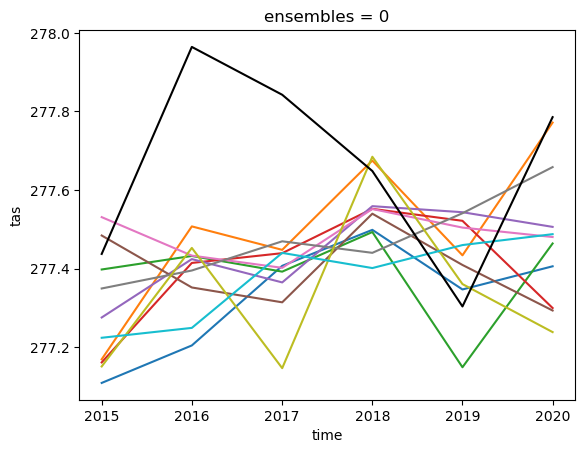

In [72]:
for i in range(10):
    ds[i].mean(['lat', 'lon'])[:,110].plot()
# ds[0].mean(['lat', 'lon'])[:,0].plot()
obs.isel(ensembles = 0).mean(['lat', 'lon']).plot(color = 'k')

In [73]:
obs_anom = obs - obs.mean('time')
ds_anom = ds - ds.mean('time')

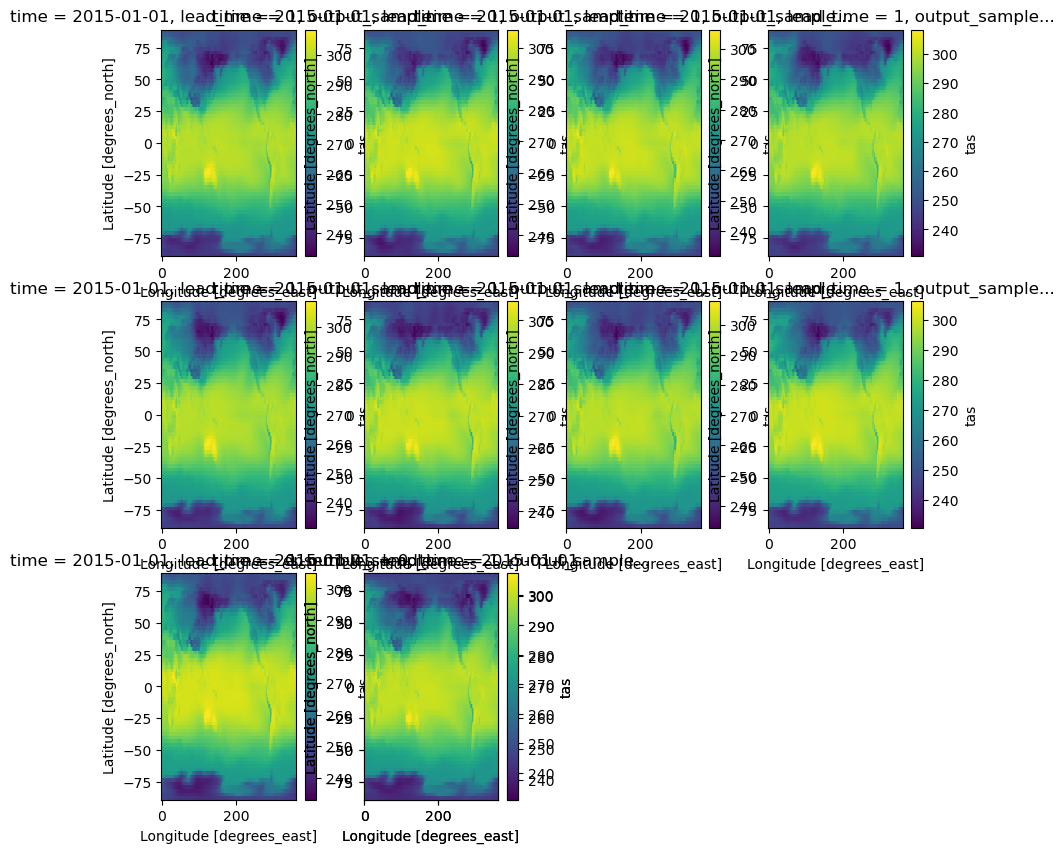

In [74]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,10))
for i in range(10):
    plt.subplot(3,4,i+1)
    ds[i,0,0,:,:].plot()
# plt.subplot(1,2,1)
# ds_anom[0,0,0,:,:].plot()
# plt.subplot(1,2,2)
plt.subplot(3,4,i+1)
obs.isel(ensembles = 0)[:,:,0].plot()

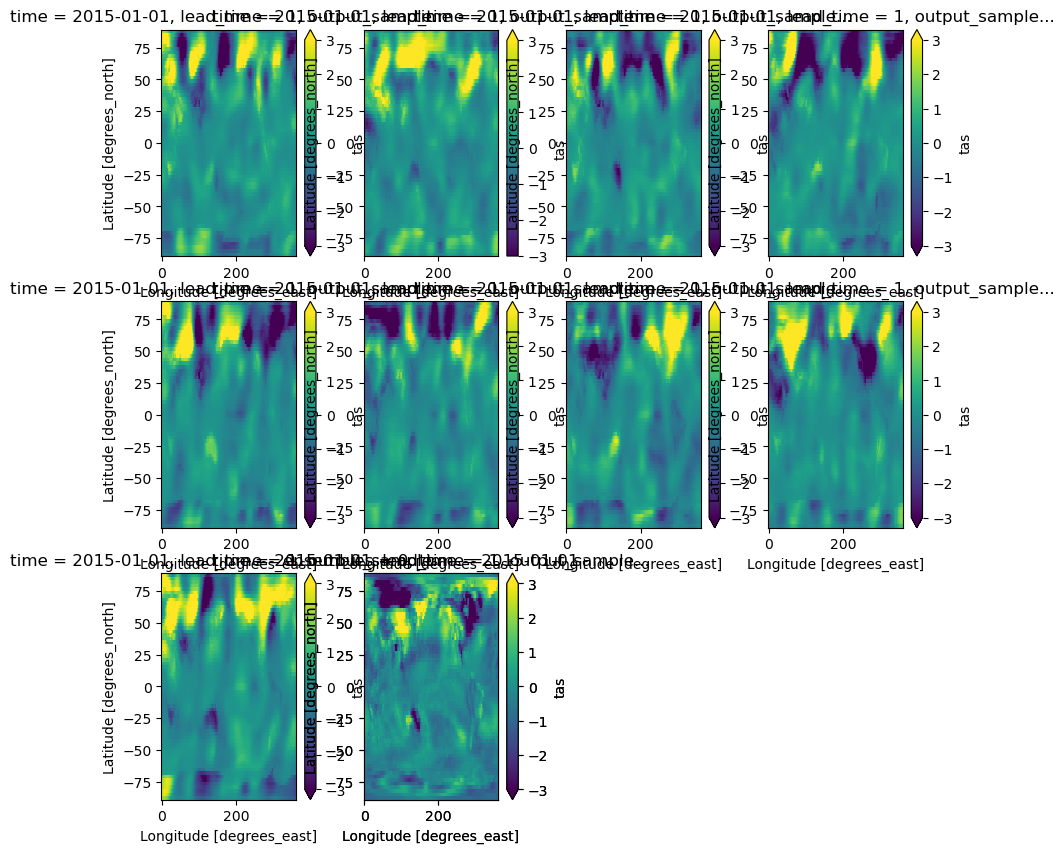

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,10))
for i in range(10):
    plt.subplot(3,4,i+1)
    ds_anom[i,0,0,:,:].plot(vmin = -3, vmax = 3)
# plt.subplot(1,2,1)
# ds_anom[0,0,0,:,:].plot()
# plt.subplot(1,2,2)
plt.subplot(3,4,i+1)
obs_anom.isel(ensembles = 0)[:,:,0].plot(vmin = -3, vmax = 3)

In [1]:
import glob
import xarray as xr
import joblib

In [2]:
model = xr.open_mfdataset(glob.glob("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data/datetime/*.nc")).sel(year = slice('1990', '2010')).rename({"year" : 'time'}).mean('ensembles')
obs = xr.open_dataset("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations/ERA5/datetime/tas_era5_194001_202412_128_64.nc").sel(time = slice('1990', '2010')).mean('ensembles')

In [3]:
model_pp = joblib.load("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/output/cccma_PPP_tests/test_3/preprocessing_pipeline/model_preprocessing_pipeline.joblib")
obs_pp = joblib.load("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/output/cccma_PPP_tests/test_3/preprocessing_pipeline/observation_preprocessing_pipeline.joblib")

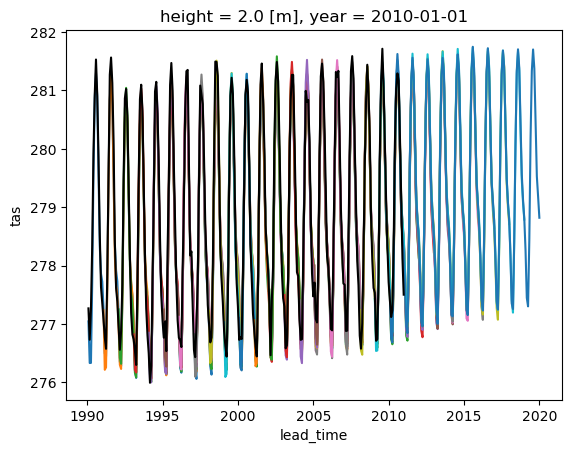

In [ ]:
import matplotlib.pyplot as plt


for t in model.tas.time:
    model.tas.sel(time = t).mean(['lat','lon']).assign_coords(lead_time = t.dt.year + model.lead_time / 12).plot()

plt.plot(obs.tas.time.dt.year + obs.tas.time.dt.month /12, obs.tas.mean(['lat','lon']), color = 'k')

In [4]:
model_processed = model_pp.transform(model)
obs_processed = obs_pp.transform(obs)
                                 

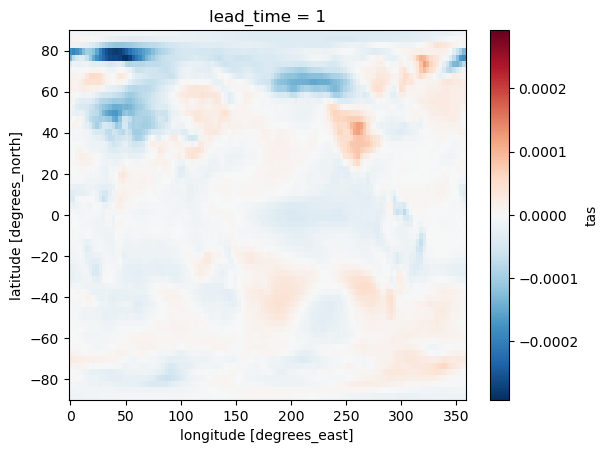

In [31]:
model_pp.get_preprocessors('trend_remover').slope.tas[0].plot()

In [5]:
model_det = model_pp.get_preprocessors('trend_remover').transform(model)

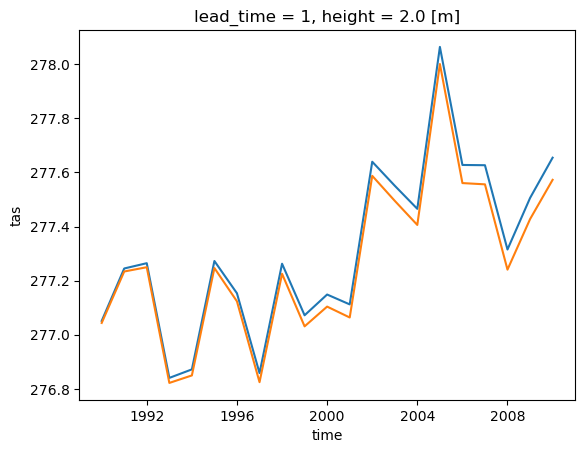

In [42]:
model_pp.get_preprocessors('trend_remover').transform(model)['tas'].mean(['lat', 'lon'])[:,0].plot()
model['tas'].mean(['lat', 'lon'])[:,0].plot()

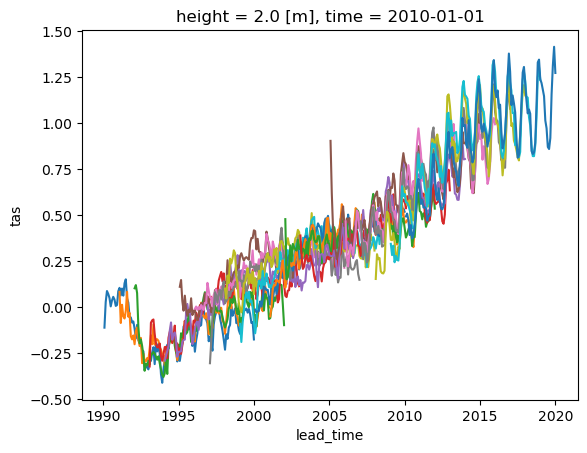

In [41]:
import matplotlib.pyplot as plt


for t in model.tas.time:
    model_processed.tas.sel(time = t).mean(['lat','lon']).assign_coords(lead_time = t.dt.year + model.lead_time / 12).plot()

# plt.plot(obs.tas.time.dt.year + obs.tas.time.dt.month /12, obs_processed.tas.mean(['lat','lon']), color = 'k')